In [3]:
import pandas as pd
import os
import kagglehub

In [4]:
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

# Assuming 'aug_train.csv' is the primary data file within the dataset directory
perf_path = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
full_csv_path = os.path.join(path, perf_path)

# Check if the file exists before attempting to read
if os.path.exists(full_csv_path):
    df = pd.read_csv(full_csv_path)
    print(f"Successfully loaded {perf_path} into a DataFrame.")
    display(df.head())
else:
    print(f"Error: The file '{perf_path}' was not found in '{path}'.")
    print("Available files in the directory:", os.listdir(path))

100%|██████████| 50.1k/50.1k [00:00<00:00, 38.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/versions/1
Successfully loaded WA_Fn-UseC_-HR-Employee-Attrition.csv into a DataFrame.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
df.shape

(1470, 35)

In [7]:
df['Attrition'] = df['Attrition'].map({'Yes': 1,
                                       'No' : 0})

In [8]:
print("Total employees:", len(df))
print("Attrition rate (%):", df['Attrition'].mean()*100)
print("Number of features:", df.shape[1])
print(f"Number of duplicated values:  {df.duplicated().sum()}")
print(f"Number of null values: {df.isnull().sum().sum()}")
print(f"Number of missing values: {df.isna().sum().sum()}")

Total employees: 1470
Attrition rate (%): 16.122448979591837
Number of features: 35
Number of duplicated values:  0
Number of null values: 0
Number of missing values: 0


In [9]:
df.dtypes.value_counts()

,count
int64,27
object,8


In [10]:
categorical_columns = df.select_dtypes(include= 'object').columns
print(categorical_columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


<Axes: >

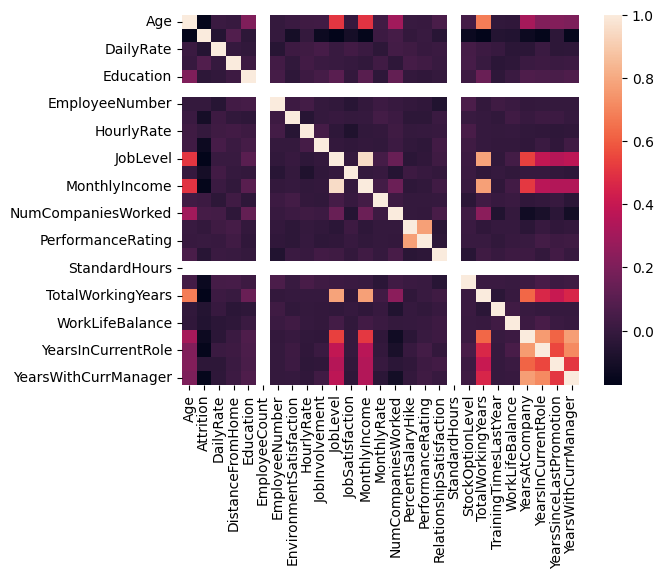

In [33]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True))

In [11]:
df['Department'].value_counts()


,count
Department,
Research & Development,961
Sales,446
Human Resources,63


Probably we are working with a product oriented company

Lets see what types of studies this people did:

In [12]:
df['EducationField'].value_counts()

,count
EducationField,
Life Sciences,606
Medical,464
Marketing,159
Technical Degree,132
Other,82
Human Resources,27


In [13]:
df.groupby('Department')['EducationField'].value_counts()

Department              EducationField  
Human Resources         Human Resources      27
                        Life Sciences        16
                        Medical              13
                        Technical Degree      4
                        Other                 3
Research & Development  Life Sciences       440
                        Medical             363
                        Technical Degree     94
                        Other                64
Sales                   Marketing           159
                        Life Sciences       150
                        Medical              88
                        Technical Degree     34
                        Other                15
Name: count, dtype: int64

If I had to guess, I would say that we are working with a Pharmaceutical/ BioTech Company

In [35]:
total_spending_month = df.groupby('Department')['MonthlyIncome'].sum().sum()
print(df.groupby('Department')['MonthlyIncome'].sum())
print(f"Total Spending: {total_spending_month}$")

Department
Human Resources            419234
Research & Development    6036284
Sales                     3103791
Name: MonthlyIncome, dtype: int64
Total Spending: 9559309$


9.5M $/month, HUGE COMPANY!

Lets explore the salary BIAS

In [36]:
import matplotlib.pyplot as plt


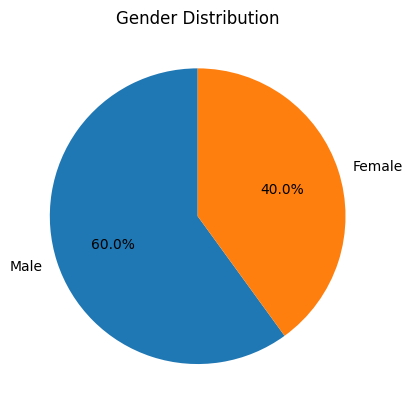

In [48]:
counts = df['Gender'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.show()

In [24]:
df['Gender'].value_counts()

,count
Gender,
Male,882
Female,588


In [23]:
#Overral wich gender receives more?
mean_by_gender = df.groupby('Gender')['MonthlyIncome'].mean()
print(f"Mean payment of each {mean_by_gender}")

Mean payment of each Gender
Female    6686.566327
Male      6380.507937
Name: MonthlyIncome, dtype: float64


In [25]:
#Now lets see if exist payment difference in the same jobRole
df.groupby(['JobRole', 'Gender'])['MonthlyIncome'].mean().unstack()

Gender,Female,Male
JobRole,,
Healthcare Representative,7433.803922,7589.300000
Human Resources,4540.687500,4100.222222
Laboratory Technician,3246.905882,3232.413793
Manager,16915.276596,17409.327273
Manufacturing Director,7409.166667,7182.671233
Research Director,15144.484848,16657.787234
Research Scientist,3344.473684,3173.044944
Sales Executive,6764.310606,7033.123711
Sales Representative,2671.947368,2587.200000


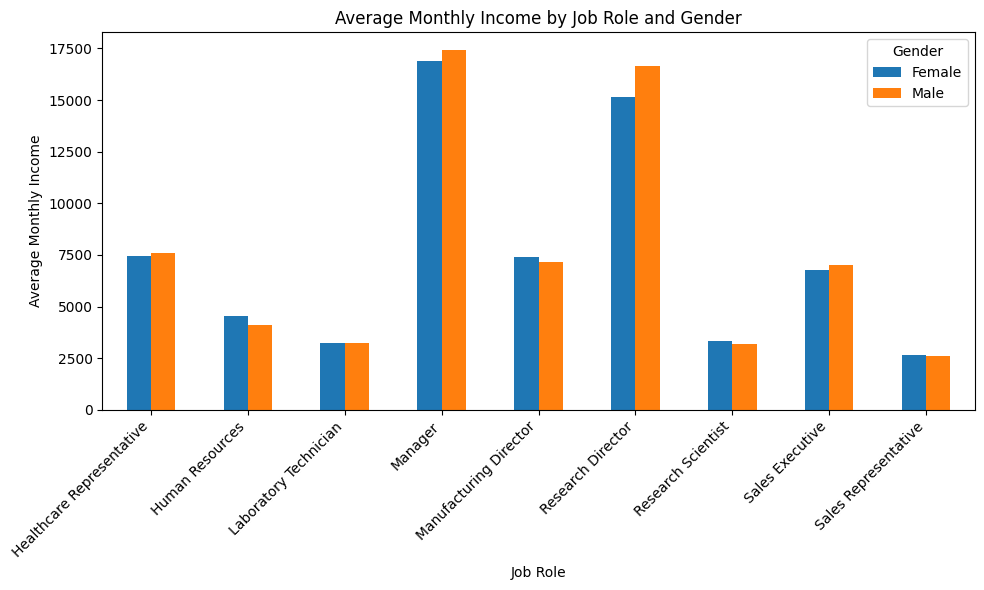

In [49]:
pivot = df.groupby(['JobRole', 'Gender'])['MonthlyIncome'].mean().unstack()

pivot.plot(kind='bar', figsize=(10,6))

plt.title('Average Monthly Income by Job Role and Gender')
plt.ylabel('Average Monthly Income')
plt.xlabel('Job Role')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [26]:
#What about jobLevel
df.groupby(['JobLevel', 'Gender'])['MonthlyIncome'].mean().unstack()

Gender,Female,Male
JobLevel,,
1,2780.487437,2790.633721
2,5435.327273,5549.184713
3,9962.702128,9706.991935
4,15431.372549,15570.927273
5,19129.916667,19224.844444


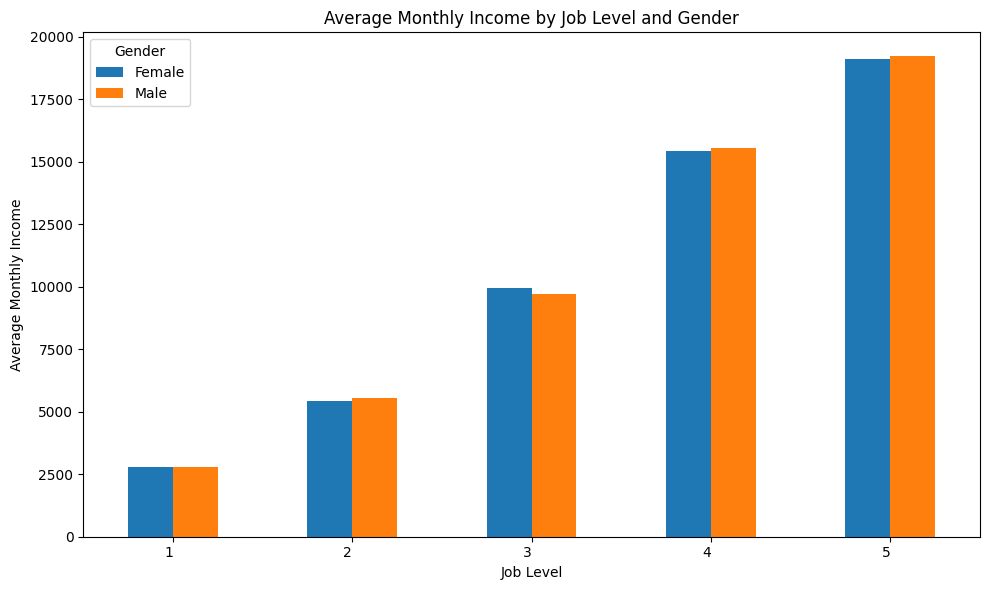

In [52]:
pivot = df.groupby(['JobLevel', 'Gender'])['MonthlyIncome'].mean().unstack()

pivot.plot(kind='bar', figsize=(10,6))

plt.title('Average Monthly Income by Job Level and Gender')
plt.ylabel('Average Monthly Income')
plt.xlabel('Job Level')
plt.xticks(rotation=0, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [27]:
df.groupby(
    ['JobRole', 'JobLevel', 'Gender']
)['MonthlyIncome'].mean().unstack()

Gender                                    Female          Male
JobRole                   JobLevel                            
Healthcare Representative 2          5882.838710   5853.808511
                          3          9123.058824   9515.629630
                          4         13888.000000  12515.500000
Human Resources           1          2653.000000   2768.086957
                          2          5859.333333   5474.700000
                          3          9514.333333   9731.666667
Laboratory Technician     1          2821.208955   2871.406015
                          2          4680.176471   4357.743590
                          3          7403.000000   5295.500000
Manager                   3         12376.000000  12032.800000
                          4         16657.086957  16571.291667
                          5         19133.705882  19216.846154
Manufacturing Director    2          5259.731707   5908.142857
                          3          9189.391304   9430.045455
                          4         13306.875000  13687.500000
Research Director         3         12652.000000  12814.333333
                          4         16349.100000  16479.000000
                          5         19120.714286  19235.789474
Research Scientist        1          2869.873563   2802.659864
                          2          4873.740741   4769.566667
                          3                  NaN   9724.000000
Sales Executive           2          5669.142857   5896.518519
                          3          9075.407407   9150.730769
                          4         13182.428571  13222.571429
Sales Representative      1          2516.771429   2498.146341
                          2          4482.333333   3500.000000

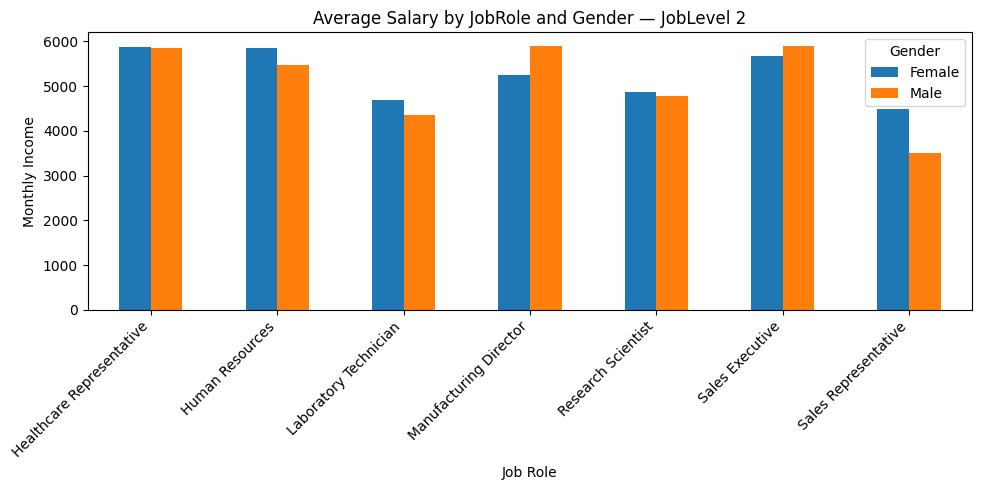

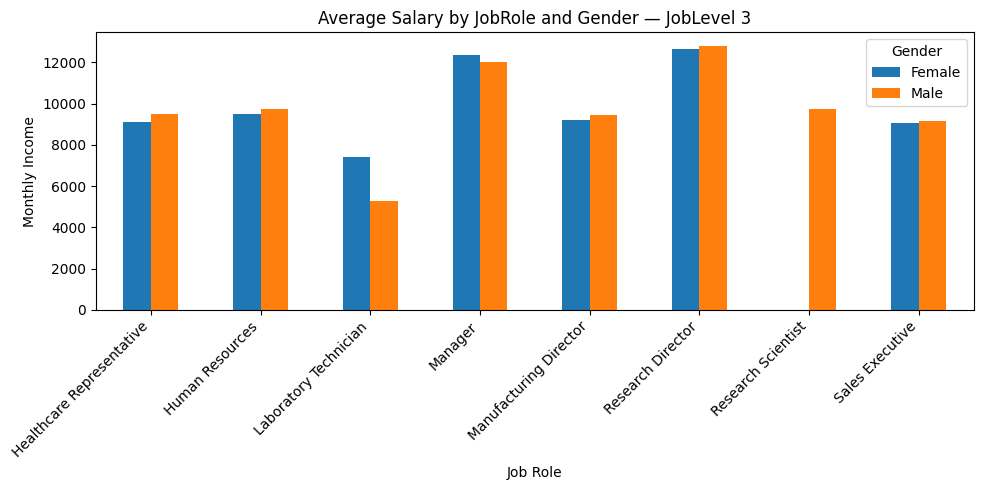

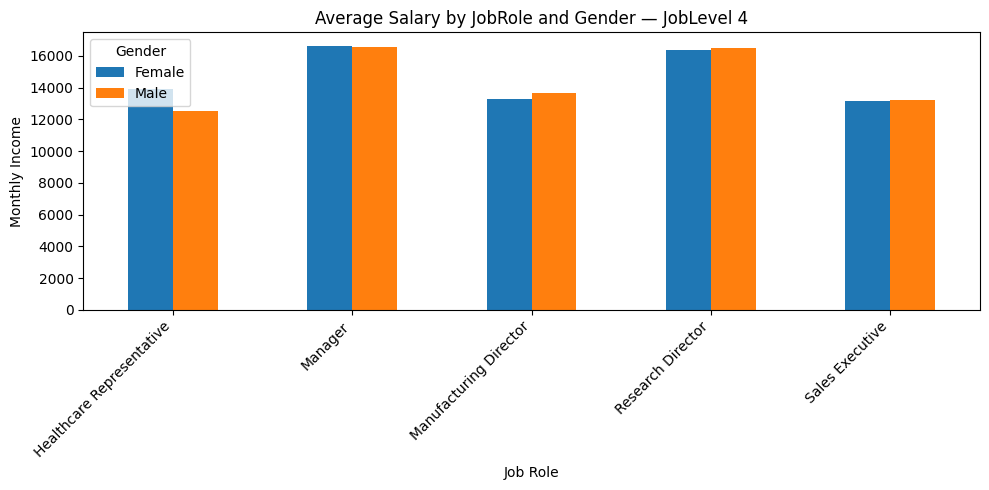

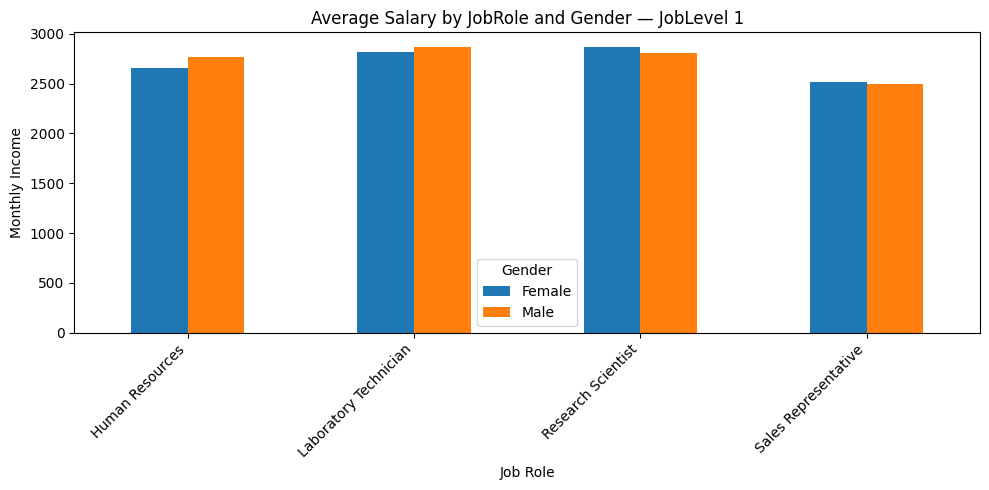

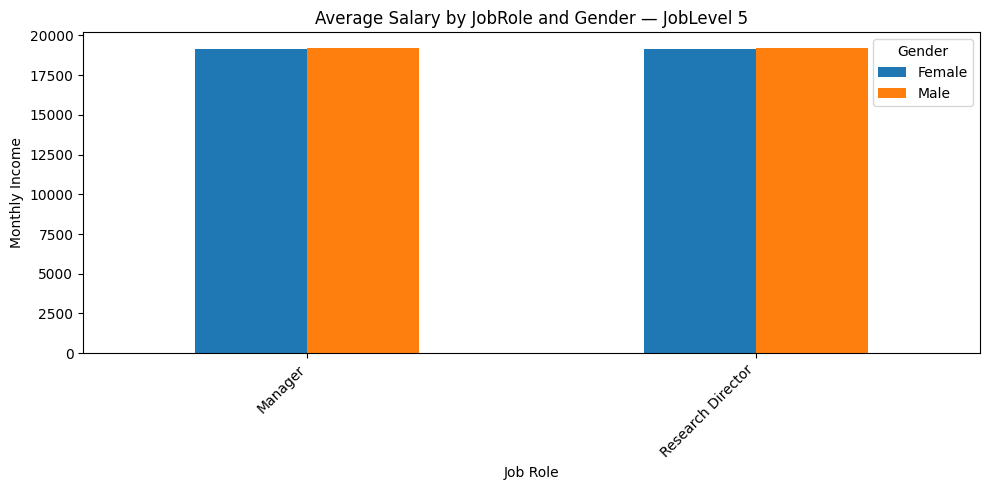

In [55]:
levels = pivot.index.get_level_values('JobLevel').unique()

for lvl in levels:
    data = pivot.xs(lvl, level='JobLevel')

    data.plot(kind='bar', figsize=(10,5))
    plt.title(f'Average Salary by JobRole and Gender — JobLevel {lvl}')
    plt.ylabel('Monthly Income')
    plt.xlabel('Job Role')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Gender')
    plt.tight_layout()
    plt.show()

In [28]:
df.groupby(
    ['JobLevel', 'Gender']
).agg(
    avg_salary=('MonthlyIncome', 'mean'),
    avg_experience=('TotalWorkingYears', 'mean')
)

avg_salary  avg_experience
JobLevel Gender                              
1        Female   2780.487437        6.030151
         Male     2790.633721        5.811047
2        Female   5435.327273       10.486364
         Male     5549.184713       10.378981
3        Female   9962.702128       15.872340
         Male     9706.991935       14.548387
4        Female  15431.372549       25.098039
         Male    15570.927273       25.818182
5        Female  19129.916667       25.666667
         Male    19224.844444       26.755556

In [50]:
import statsmodels.formula.api as smf

model = smf.ols("""
MonthlyIncome ~
C(Gender) +
C(JobLevel) +
C(JobRole) +
TotalWorkingYears +
YearsAtCompany +
PerformanceRating +
Education
""", data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyIncome   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     1632.
Date:                Sat, 07 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:30:29   Log-Likelihood:                -12311.
No. Observations:                1470   AIC:                         2.466e+04
Df Residuals:                    1452   BIC:                         2.475e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
